In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed= 42

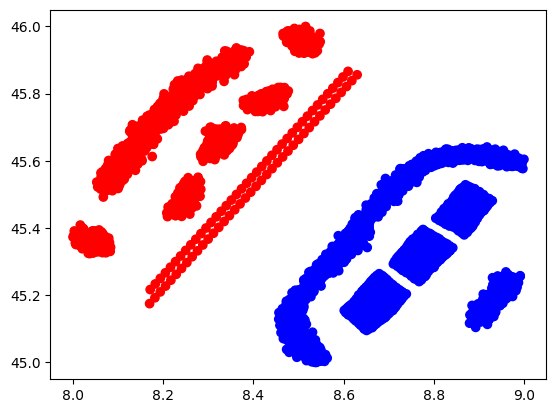

In [16]:
train_df= pd.read_csv("data.csv")

X= train_df.drop(columns=['ID','Team'])

plt.scatter(train_df['x'], train_df['y'], c= train_df['Team'].map({0: 'red', 1: 'blue'}))
plt.show()

In [17]:
# Subtask 1
from sklearn.neighbors import NearestNeighbors

team0 = train_df[train_df['Team'] == 0].copy()

coords = team0[['x', 'y']].values

nn = NearestNeighbors(n_neighbors=2)
nn.fit(coords)

distances, _ = nn.kneighbors(coords)

team0['isolation_score'] = distances[:,1]

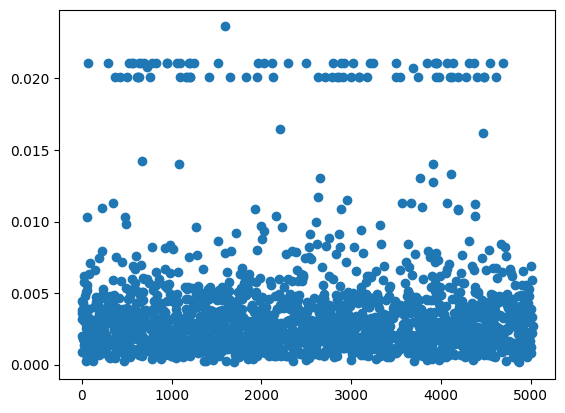

In [18]:
plt.scatter(team0.index, team0['isolation_score'])
plt.show()

In [19]:
team0pos= 0

answer1= []

for _, row in train_df.iterrows():
    if row['Team']== 0:
        answer1.append({
        'subtaskID': 1,
        'datapointID': row['ID'],
        'answer':  1 if team0['isolation_score'].iloc[team0pos] >= 0.017 else 0
        })
        team0pos+= 1
    else:
        answer1.append({
        'subtaskID': 1,
        'datapointID': row['ID'],
        'answer':  0
        })

answer1= pd.DataFrame(answer1)
answer1.head()

,subtaskID,datapointID,answer
0,1,2472.0,0
1,1,4081.0,0
2,1,2643.0,0
3,1,2719.0,0
4,1,4975.0,0


In [20]:
# Subtask 2
from sklearn.cluster import HDBSCAN

model= HDBSCAN()

predictions= model.fit_predict(X)

answer2=[]
for id_, pred in zip(train_df['ID'], predictions):
    answer2.append({
        'subtaskID': 2,
        'datapointID': id_,
        'answer': f"{pred:.0f}"
        })

answer2= pd.DataFrame(answer2)
answer2.head()

,subtaskID,datapointID,answer
0,2,2472,2
1,2,4081,5
2,2,2643,8
3,2,2719,10
4,2,4975,5


In [21]:
answer= pd.concat([answer1, answer2])
answer.to_csv("submission.csv", index= False)